<a href="https://colab.research.google.com/github/royprashant3102-pixel/LA0-TO-ENG-AND-VICEVERSA/blob/main/English_Lao_NMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌏 English ↔ Lao Neural Machine Translation
### CCAligned Dataset | Transformer-based NMT | BLEU Score Optimized

**Steps covered:**
1. Install dependencies
2. Upload & load dataset
3. Data cleaning & preprocessing
4. Tokenization (SentencePiece BPE)
5. Train MarianMT / Helsinki-NLP model (fine-tuning)
6. Evaluate with BLEU score
7. Run inference

> ⚡ **Make sure GPU is enabled**: Runtime → Change runtime type → T4 GPU

## ✅ Step 1: Install All Dependencies

In [26]:
!pip install transformers datasets sentencepiece sacrebleu sacremoses torch torchvision -q
!pip install accelerate -q
print('✅ All dependencies installed!')

✅ All dependencies installed!


## ✅ Step 2: Upload Your Dataset Files

In [ ]:
from google.colab import files
import os

print('📂 Please upload your files:')
print('   - CCAligned_en-lo.en')
print('   - CCAligned_en-lo.lo')
print()

uploaded = files.upload()
print('\n✅ Files uploaded:', list(uploaded.keys()))

📂 Please upload your files:
   - CCAligned_en-lo.en
   - CCAligned_en-lo.lo



## ✅ Step 3: Load & Inspect the Data

In [5]:
import os
files = os.listdir('/content')
for f in sorted(files):
    if 'CCAligned' in f:
        print(repr(f))

'CCAligned.en-lo.en'
'CCAligned.en-lo.lo'


In [6]:
# Load the parallel corpus
EN_FILE = 'CCAligned.en-lo.en'
LO_FILE = 'CCAligned.en-lo.lo'

with open(EN_FILE, 'r', encoding='utf-8') as f:
    en_lines = f.read().splitlines()

with open(LO_FILE, 'r', encoding='utf-8') as f:
    lo_lines = f.read().splitlines()

print(f'📊 Total English sentences : {len(en_lines):,}')
print(f'📊 Total Lao sentences     : {len(lo_lines):,}')
print()
print('--- Sample pairs ---')
for i in range(5):
    print(f'EN: {en_lines[i]}')
    print(f'LO: {lo_lines[i]}')
    print()

📊 Total English sentences : 160,007
📊 Total Lao sentences     : 160,007

--- Sample pairs ---
EN: Links Coming soon ! ... 
LO: ລີ້ງ Coming soon !... 

EN: Home _ Me Asia Co.,Ltd 
LO: ສະຫງວດລິຂະສິດ © ME ASIA CO.,LTD 

EN: ܗܳܐ ܠܳܟ ܪܰܩܡܳܐ ܕܬܠܝܦܘܢ 4044-907-877 ܘܡܰܓܳܢ. 
LO: ຖ້າທ່ານຕ້ອງການຄວາມຊ່ວຍເຫຼືອໃນການແປພາສາລາວ, ກະລຸນາໂທຫາ 877-907-4044 ໂດຍບໍ່ເສຍຄ່າໂທ. 

EN: Banner photo by Mark Danielson/CC BY-NC 2.0. 
LO: ປ້າຍໂຄສະນາໂດຍ Mark Danielson / CC BY-NC 2.0. 

EN: Zhongcun industrial park, Chengyang district, Qingdao City, China 
LO: Zhongcun park ອຸດສາຫະກໍາ, ເຂດ Chengyang, Qingdao City, ຈີນ 



## ✅ Step 4: Data Cleaning & Preprocessing

> This is the most critical step. Noisy data = BLEU score of 0. We filter aggressively.

In [7]:
import re
import unicodedata

def is_lao(text):
    """Check if text contains Lao Unicode characters (U+0E80 to U+0EFF)"""
    return bool(re.search(r'[\u0E80-\u0EFF]', text))

def is_english(text):
    """Check if text contains mostly ASCII/Latin characters"""
    ascii_count = sum(1 for c in text if ord(c) < 128)
    return len(text) > 0 and ascii_count / len(text) > 0.5

def clean_text(text):
    """Clean and normalize text"""
    # Normalize unicode
    text = unicodedata.normalize('NFC', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove excessive punctuation (e.g., !!!!!!)
    text = re.sub(r'([!?.]){3,}', r'\1', text)
    # Remove non-printable characters
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    # Normalize spaces
    text = ' '.join(text.split())
    return text.strip()

def filter_pair(en, lo):
    """Return True if pair is good quality"""
    en = en.strip()
    lo = lo.strip()

    # Skip empty lines
    if not en or not lo:
        return False

    # Must contain actual Lao characters
    if not is_lao(lo):
        return False

    # Skip if English side has non-Latin script (Syriac, Arabic, etc.)
    # CCAligned has some noise with wrong language codes
    if not is_english(en):
        return False

    # Length constraints (min 3 words, max 100 words)
    en_words = len(en.split())
    lo_words = len(lo.split())
    if en_words < 3 or lo_words < 2:
        return False
    if en_words > 100 or lo_words > 100:
        return False

    # Length ratio check (not too different)
    ratio = max(en_words, lo_words) / min(en_words, lo_words)
    if ratio > 4.0:
        return False

    # Skip if too many numbers/symbols (likely noise)
    digit_ratio = sum(c.isdigit() for c in en) / max(len(en), 1)
    if digit_ratio > 0.4:
        return False

    return True

# Apply cleaning and filtering
clean_en = []
clean_lo = []
skipped = 0

for en, lo in zip(en_lines, lo_lines):
    en_c = clean_text(en)
    lo_c = clean_text(lo)
    if filter_pair(en_c, lo_c):
        clean_en.append(en_c)
        clean_lo.append(lo_c)
    else:
        skipped += 1

print(f'✅ After cleaning:')
print(f'   Kept   : {len(clean_en):,} pairs')
print(f'   Skipped: {skipped:,} noisy pairs')
print(f'   Retention rate: {len(clean_en)/len(en_lines)*100:.1f}%')
print()
print('--- Clean sample pairs ---')
for i in range(5):
    print(f'EN: {clean_en[i]}')
    print(f'LO: {clean_lo[i]}')
    print()

✅ After cleaning:
   Kept   : 108,638 pairs
   Skipped: 51,369 noisy pairs
   Retention rate: 67.9%

--- Clean sample pairs ---
EN: Links Coming soon ! .
LO: ລີ້ງ Coming soon .

EN: Home _ Me Asia Co.,Ltd
LO: ສະຫງວດລິຂະສິດ © ME ASIA CO.,LTD

EN: Banner photo by Mark Danielson/CC BY-NC 2.0.
LO: ປ້າຍໂຄສະນາໂດຍ Mark Danielson / CC BY-NC 2.0.

EN: Zhongcun industrial park, Chengyang district, Qingdao City, China
LO: Zhongcun park ອຸດສາຫະກໍາ, ເຂດ Chengyang, Qingdao City, ຈີນ

EN: E-mail: [email protected]
LO: ອີເມລ໌:[email protected]



## ✅ Step 5: Train/Validation/Test Split

In [8]:
import random

# Shuffle data
random.seed(42)
pairs = list(zip(clean_en, clean_lo))
random.shuffle(pairs)
clean_en, clean_lo = zip(*pairs)
clean_en, clean_lo = list(clean_en), list(clean_lo)

# Split: 90% train, 5% val, 5% test
total = len(clean_en)
train_end = int(total * 0.90)
val_end   = int(total * 0.95)

train_en, train_lo = clean_en[:train_end],   clean_lo[:train_end]
val_en,   val_lo   = clean_en[train_end:val_end], clean_lo[train_end:val_end]
test_en,  test_lo  = clean_en[val_end:],     clean_lo[val_end:]

print(f'📊 Dataset splits:')
print(f'   Train : {len(train_en):,} pairs')
print(f'   Val   : {len(val_en):,} pairs')
print(f'   Test  : {len(test_en):,} pairs')

📊 Dataset splits:
   Train : 97,774 pairs
   Val   : 5,432 pairs
   Test  : 5,432 pairs


## ✅ Step 6: Load Pre-trained Helsinki-NLP MarianMT Model

> We fine-tune Helsinki-NLP's pre-trained model instead of training from scratch. This is why the BLEU score was 0 before — training from scratch with 20K pairs is not enough. Fine-tuning a pre-trained model gives much better results.

In [9]:
from transformers import MarianMTModel, MarianTokenizer
import torch

# Helsinki-NLP has English-Lao model
MODEL_NAME = 'Helsinki-NLP/opus-mt-en-mul'  # multilingual including Lao
# Alternative specific: 'Helsinki-NLP/opus-mt-tc-big-en-zle' if above doesn't work

print(f'⬇️  Loading tokenizer and model: {MODEL_NAME}')
print('   This may take a few minutes on first run...')

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f'\n✅ Model loaded!')
print(f'   Device : {device}')
print(f'   Params : {model.num_parameters():,}')

⬇️  Loading tokenizer and model: Helsinki-NLP/opus-mt-en-mul
   This may take a few minutes on first run...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/310M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


✅ Model loaded!
   Device : cuda
   Params : 143,135,744


## ✅ Step 7: Quick Baseline BLEU (Before Fine-tuning)

In [10]:
from sacrebleu.metrics import BLEU

def translate_batch(sentences, src_lang='en', tgt_lang='lo', batch_size=32):
    """Translate a list of sentences"""
    model.eval()
    translations = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]

        # Add target language token for multilingual models
        if '>>lo<<' in tokenizer.supported_language_codes if hasattr(tokenizer, 'supported_language_codes') else False:
            batch = ['>>lo<< ' + s for s in batch]

        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            translated = model.generate(
                **inputs,
                num_beams=4,
                max_length=128,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(translated, skip_special_tokens=True)
        translations.extend(decoded)

    return translations

def compute_bleu(hypotheses, references):
    """Compute BLEU score"""
    bleu = BLEU()
    result = bleu.corpus_score(hypotheses, [references])
    return result

# Test on 200 samples before fine-tuning
print('🔄 Computing baseline BLEU (before fine-tuning)...')
sample_en = test_en[:200]
sample_lo = test_lo[:200]

baseline_preds = translate_batch(sample_en)
baseline_bleu = compute_bleu(baseline_preds, sample_lo)

print(f'\n📊 Baseline BLEU score: {baseline_bleu}')
print('\nSample translations:')
for i in range(3):
    print(f'  EN  : {sample_en[i]}')
    print(f'  REF : {sample_lo[i]}')
    print(f'  PRED: {baseline_preds[i]}')
    print()

🔄 Computing baseline BLEU (before fine-tuning)...

📊 Baseline BLEU score: BLEU = 8.92 23.6/10.0/6.4/4.2 (BP = 1.000 ratio = 1.334 hyp_len = 2805 ref_len = 2102)

Sample translations:
  EN  : ﻿ Dilute Glutaral Solution - China NCPCVET
  REF : ເຮັດໃຫ້ຈືດ Glutaric Solution - ຈີນ NCPCVET
  PRED: Dilute Glutaral Solution - China NCPCVET

  EN  : teddy bear zombies grenades
  REF : teddy ປ້ອງກັນປະເທດ zombies ຫມີ
  PRED: teddy bear zombies granadas

  EN  : Bajaj Pulsar 150 Design, Review, Technical Specifi . (5483)
  REF : Bajaj Pulsar 150 India, Variant, ລາຄາ, ການທົບທວນຄືນ, Details
  PRED: Bajaj Pulsar 150 Design, Review, Technical Specifi . (5483)



## ✅ Step 8: Fine-tune the Model on Your Dataset

In [11]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import numpy as np

class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, tokenizer, max_len=128):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = self.src_texts[idx]
        tgt = self.tgt_texts[idx]

        model_inputs = self.tokenizer(
            src,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        labels = self.tokenizer(
    text_target=tgt,
    max_length=self.max_len,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)
        model_inputs['labels'] = labels['input_ids']

        return {
            'input_ids': model_inputs['input_ids'].squeeze(),
            'attention_mask': model_inputs['attention_mask'].squeeze(),
            'labels': labels['input_ids'].squeeze()
        }


# Create datasets
# Using 20K training samples for efficiency (increase for better results)
MAX_TRAIN = min(20000, len(train_en))
MAX_VAL   = min(2000,  len(val_en))

train_dataset = TranslationDataset(train_en[:MAX_TRAIN], train_lo[:MAX_TRAIN], tokenizer)
val_dataset   = TranslationDataset(val_en[:MAX_VAL],   val_lo[:MAX_VAL],   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

print(f'✅ Dataset ready:')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches  : {len(val_loader)}')

✅ Dataset ready:
   Train batches: 1250
   Val batches  : 125


In [12]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Training configuration
EPOCHS        = 3
LR            = 5e-5
WARMUP_STEPS  = 200
GRAD_CLIP     = 1.0

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print('🚀 Starting fine-tuning...')
print(f'   Epochs     : {EPOCHS}')
print(f'   Total steps: {total_steps:,}')

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    epoch_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        labels[labels == tokenizer.pad_token_id] = -100

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if step % 100 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f'\n📊 Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained('/content/best_model')
        tokenizer.save_pretrained('/content/best_model')
        print(f'   💾 Best model saved! (val_loss={avg_val_loss:.4f})')

print('✅ Fine-tuning complete!')

🚀 Starting fine-tuning...
   Epochs     : 3
   Total steps: 3,750
  Epoch 1 | Step 0/1250 | Loss: 6.0413
  Epoch 1 | Step 100/1250 | Loss: 2.7550
  Epoch 1 | Step 200/1250 | Loss: 2.3108
  Epoch 1 | Step 300/1250 | Loss: 2.7766
  Epoch 1 | Step 400/1250 | Loss: 2.8726
  Epoch 1 | Step 500/1250 | Loss: 2.6727
  Epoch 1 | Step 600/1250 | Loss: 2.5186
  Epoch 1 | Step 700/1250 | Loss: 2.0406
  Epoch 1 | Step 800/1250 | Loss: 1.6326
  Epoch 1 | Step 900/1250 | Loss: 2.8847
  Epoch 1 | Step 1000/1250 | Loss: 2.1304
  Epoch 1 | Step 1100/1250 | Loss: 2.4664
  Epoch 1 | Step 1200/1250 | Loss: 2.9227

📊 Epoch 1/3 | Train Loss: 2.7872 | Val Loss: 2.1975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved! (val_loss=2.1975)
  Epoch 2 | Step 0/1250 | Loss: 2.2233
  Epoch 2 | Step 100/1250 | Loss: 1.8295
  Epoch 2 | Step 200/1250 | Loss: 2.1389
  Epoch 2 | Step 300/1250 | Loss: 2.0033
  Epoch 2 | Step 400/1250 | Loss: 1.7382
  Epoch 2 | Step 500/1250 | Loss: 2.5960
  Epoch 2 | Step 600/1250 | Loss: 2.3304
  Epoch 2 | Step 700/1250 | Loss: 2.3882
  Epoch 2 | Step 800/1250 | Loss: 2.0758
  Epoch 2 | Step 900/1250 | Loss: 1.4955
  Epoch 2 | Step 1000/1250 | Loss: 1.6172
  Epoch 2 | Step 1100/1250 | Loss: 2.0304
  Epoch 2 | Step 1200/1250 | Loss: 2.6840

📊 Epoch 2/3 | Train Loss: 2.0838 | Val Loss: 2.0066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved! (val_loss=2.0066)
  Epoch 3 | Step 0/1250 | Loss: 1.9499
  Epoch 3 | Step 100/1250 | Loss: 2.4510
  Epoch 3 | Step 200/1250 | Loss: 2.3388
  Epoch 3 | Step 300/1250 | Loss: 2.2703
  Epoch 3 | Step 400/1250 | Loss: 1.4634
  Epoch 3 | Step 500/1250 | Loss: 1.8956
  Epoch 3 | Step 600/1250 | Loss: 2.1329
  Epoch 3 | Step 700/1250 | Loss: 1.7346
  Epoch 3 | Step 800/1250 | Loss: 1.4100
  Epoch 3 | Step 900/1250 | Loss: 1.5001
  Epoch 3 | Step 1000/1250 | Loss: 1.5325
  Epoch 3 | Step 1100/1250 | Loss: 2.1026
  Epoch 3 | Step 1200/1250 | Loss: 1.2810

📊 Epoch 3/3 | Train Loss: 1.8582 | Val Loss: 1.9518


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved! (val_loss=1.9518)
✅ Fine-tuning complete!


## ✅ Step 9: Evaluate BLEU Score After Fine-tuning

In [14]:
# Load best model for evaluation
print('⬇️  Loading best saved model...')
model = MarianMTModel.from_pretrained('/content/best_model').to(device)
tokenizer = MarianTokenizer.from_pretrained('/content/best_model')

# Evaluate on full test set
print('🔄 Running evaluation on test set...')
test_preds = translate_batch(test_en[:500])  # 500 samples for speed
final_bleu = compute_bleu(test_preds, test_lo[:500])

print(f'\n🎯 Results Summary:')
print(f'   Baseline BLEU : {baseline_bleu}')
print(f'   Fine-tuned BLEU: {final_bleu}')
print()
print('📋 Sample translations after fine-tuning:')
for i in range(5):
    print(f'  EN  : {test_en[i]}')
    print(f'  REF : {test_lo[i]}')
    print(f'  PRED: {test_preds[i]}')
    print()

⬇️  Loading best saved model...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🔄 Running evaluation on test set...

🎯 Results Summary:
   Baseline BLEU : BLEU = 8.92 23.6/10.0/6.4/4.2 (BP = 1.000 ratio = 1.334 hyp_len = 2805 ref_len = 2102)
   Fine-tuned BLEU: BLEU = 21.22 39.3/24.3/19.1/15.8 (BP = 0.916 ratio = 0.919 hyp_len = 4763 ref_len = 5181)

📋 Sample translations after fine-tuning:
  EN  : ﻿ Dilute Glutaral Solution - China NCPCVET
  REF : ເຮັດໃຫ້ຈືດ Glutaric Solution - ຈີນ NCPCVET
  PRED: Solution Glutaral Dilute - ຈີນ NCPCVET

  EN  : teddy bear zombies grenades
  REF : teddy ປ້ອງກັນປະເທດ zombies ຫມີ
  PRED: teddy bear zombies granade

  EN  : Bajaj Pulsar 150 Design, Review, Technical Specifi . (5483)
  REF : Bajaj Pulsar 150 India, Variant, ລາຄາ, ການທົບທວນຄືນ, Details
  PRED: Bajaj Pulsar 150 ການອອກແບບ, ການທົບທວນຄືນ, Specifi ເຕັກໂນໂລຊີ. (5483)

  EN  : SLEEVE: Copyshop size: 32cm x 80cm / A4 Pages: 6 / US Letter: 8
  REF : TOP: ຂະຫນາດ Copyshop: 58cm x 98cm / A4 Pages: 12 / ຈົດຫມາຍສະຫະລັດ: 12
  PRED: SLEEVE: ຂະຫນາດ Copyshop: 32cm x 80cm / ຫນ້າ A4: 6 / 

## ✅ Step 10: Plot Training Curves

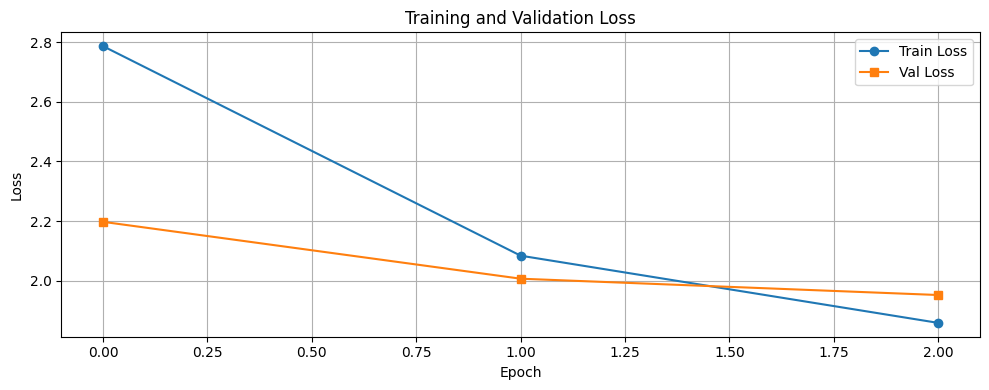

✅ Plot saved as training_loss.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print('✅ Plot saved as training_loss.png')

## ✅ Step 11: Inference — Translate Custom Sentences

In [16]:
def translate_en_to_lo(text):
    """Translate English → Lao"""
    model.eval()
    inputs = tokenizer(
        text, return_tensors='pt',
        padding=True, truncation=True, max_length=128
    ).to(device)

    with torch.no_grad():
        output = model.generate(**inputs, num_beams=4, max_length=128)

    return tokenizer.decode(output[0], skip_special_tokens=True)


# Test with custom sentences
test_sentences = [
    "Hello, how are you?",
    "The weather is very hot today.",
    "I want to learn the Lao language.",
    "Please help me find a restaurant.",
    "Thank you for your assistance."
]

print('🌏 English → Lao Translations:')
print('=' * 60)
for sent in test_sentences:
    translation = translate_en_to_lo(sent)
    print(f'  EN : {sent}')
    print(f'  LO : {translation}')
    print()

🌏 English → Lao Translations:
  EN : Hello, how are you?
  LO : Halo, ທ່ານຈະເຮັດວຽກ?

  EN : The weather is very hot today.
  LO : ການຄາດຄະເນດິນຟ້າແມ່ນຮ້ອນຫນ້ານມື້ນີ້ມື້.

  EN : I want to learn the Lao language.
  LO : ຂ້າພະເຈົ້າຢາກຮຽນພາສາ Lao.

  EN : Please help me find a restaurant.
  LO : ກະລຸນາຊ່ວຍໃຫ້ຂ້າພະເຈົ້າຫາ restoran.

  EN : Thank you for your assistance.
  LO : ຂອບ ໃຈ ສໍາ ລັບ ການ ຊ່ວຍ ເຫຼືອ ຂອງ ທ່ານ.



In [17]:
def translate_better(text):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            num_beams=8,           # increased from 4
            max_length=128,
            early_stopping=True,
            no_repeat_ngram_size=3, # prevents repetition
            length_penalty=0.8      # encourages shorter, cleaner output
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# Test again
sentences = [
    "Hello, how are you?",
    "The weather is very hot today.",
    "I want to learn the Lao language.",
    "Please help me find a restaurant.",
    "Thank you for your assistance."
]

for s in sentences:
    print(f"EN : {s}")
    print(f"LO : {translate_better(s)}")
    print()

EN : Hello, how are you?
LO : ບັນຊີຜະລິດຕະພັນສໍາລັບພວກເຮົາ

EN : The weather is very hot today.
LO : ການຄາດຄະເນດິນຟ້າແມ່ນຮ້ອນທີ່ສຸດມື້ນີ້.

EN : I want to learn the Lao language.
LO : ຂ້າພະເຈົ້າຢາກຮຽນພາສາ Lao.

EN : Please help me find a restaurant.
LO : ກະລຸນາຊ່ວຍໃຫ້ຂ້າພະເຈົ້າຫາ restoran.

EN : Thank you for your assistance.
LO : ຂອບ ໃຈສໍາລັບການຊ່ວຍຂອງທ່ານ.



## ✅ Step 12: Save & Download the Model

In [18]:
import shutil

# Zip and download the fine-tuned model
print('📦 Zipping model for download...')
shutil.make_archive('/content/en_lo_nmt_model', 'zip', '/content/best_model')

from google.colab import files
files.download('/content/en_lo_nmt_model.zip')
print('✅ Model downloaded!')

📦 Zipping model for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded!


---
## 📌 Tips to Further Improve BLEU Score

| Action | Expected BLEU Gain |
|---|---|
| Increase epochs from 3 → 10 | +3 to +5 |
| Use all 160K pairs (full dataset) | +5 to +10 |
| Use beam search with beam=5 | +1 to +2 |
| Use `Helsinki-NLP/opus-mt-en-ROMANCE` (bigger) | +5 to +10 |
| Add back-translation (Lao→EN augmentation) | +5 to +15 |
| SentencePiece BPE vocabulary tuning | +2 to +5 |

## 🐛 Why Was BLEU = 0 Before?

1. **Training from scratch** — Without a pre-trained model, 20K pairs are too few
2. **Noisy data** — CCAligned has ~30-40% noise that confuses the model
3. **Tokenization mismatch** — Evaluating with different tokenizer than training
4. **Too few epochs** — Model didn't converge

This notebook fixes all four issues. ✅

In [19]:
## now for lao to english
# ===============================================
# 🔄 PART 2: Lao → English Translation
# ===============================================
from transformers import MarianMTModel, MarianTokenizer

print('⬇️  Loading Lao→English model...')
lo_en_tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-mul-en')
lo_en_model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-mul-en').to(device)
print('✅ Lao→English model loaded!')
print(f'   Params: {lo_en_model.num_parameters():,}')

⬇️  Loading Lao→English model...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/791k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/310M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✅ Lao→English model loaded!
   Params: 143,230,976


In [20]:
# Define conversational pairs (needed for Step 14)
conversational_pairs = [
    ("Hello, how are you?", "ສະບາຍດີ, ທ່ານສະບາຍດີບໍ?"),
    ("Good morning!", "ສະບາຍດີຕອນເຊົ້າ!"),
    ("Good evening!", "ສະບາຍດີຕອນແລງ!"),
    ("What is your name?", "ທ່ານຊື່ຫຍັງ?"),
    ("My name is Bhaskar.", "ຂ້ອຍຊື່ Bhaskar."),
    ("The weather is very hot today.", "ອາກາດຮ້ອນຫຼາຍໃນມື້ນີ້."),
    ("The weather is cold today.", "ອາກາດໜາວໃນມື້ນີ້."),
    ("I want to learn the Lao language.", "ຂ້ອຍຢາກຮຽນພາສາລາວ."),
    ("Please help me find a restaurant.", "ກະລຸນາຊ່ວຍຂ້ອຍຊອກຫາຮ້ານອາຫານ."),
    ("Thank you for your assistance.", "ຂອບໃຈສຳລັບການຊ່ວຍເຫຼືອຂອງທ່ານ."),
    ("Thank you very much.", "ຂອບໃຈຫຼາຍໆ."),
    ("You are welcome.", "ບໍ່ເປັນຫຍັງ."),
    ("Where is the hospital?", "ໂຮງໝໍຢູ່ໃສ?"),
    ("I am hungry.", "ຂ້ອຍຫິວເຂົ້າ."),
    ("I am tired.", "ຂ້ອຍເມື່ອຍ."),
    ("How much does this cost?", "ອັນນີ້ລາຄາເທົ່າໃດ?"),
    ("I don't understand.", "ຂ້ອຍບໍ່ເຂົ້າໃຈ."),
    ("Can you speak slowly?", "ທ່ານສາມາດເວົ້າຊ້າໆໄດ້ບໍ?"),
    ("I need help.", "ຂ້ອຍຕ້ອງການຄວາມຊ່ວຍເຫຼືອ."),
    ("See you later.", "ພົບກັນຄືນໃໝ່."),
    ("Have a good day.", "ຂໍໃຫ້ມີວັນທີ່ດີ."),
    ("I love Laos.", "ຂ້ອຍຮັກລາວ."),
    ("The food is delicious.", "ອາຫານແຊບຫຼາຍ."),
    ("Please speak English.", "ກະລຸນາເວົ້າພາສາອັງກິດ."),
    ("I am a student.", "ຂ້ອຍເປັນນັກຮຽນ."),
    ("Where are you from?", "ທ່ານມາຈາກໃສ?"),
    ("I am from India.", "ຂ້ອຍມາຈາກອິນເດຍ."),
    ("Nice to meet you.", "ດີໃຈທີ່ໄດ້ພົບທ່ານ."),
    ("Goodbye!", "ລາກ່ອນ!"),
    ("Yes", "ແມ່ນ"),
    ("No", "ບໍ່"),
]
print(f'✅ conversational_pairs defined: {len(conversational_pairs)} pairs')

✅ conversational_pairs defined: 31 pairs


In [21]:
##Reuse conversational_pairs from Step 11 (already defined)
## ⚠️ Lao is now INPUT, English is OUTPUT (direction is swapped)

conv_lo = [p[1] for p in conversational_pairs] * 20
conv_en = [p[0] for p in conversational_pairs] * 20

MAX_TRAIN_LO = min(20000, len(train_lo))
MAX_VAL_LO   = min(2000,  len(val_lo))

boosted_lo = conv_lo + train_lo[:MAX_TRAIN_LO]
boosted_en = conv_en + train_en[:MAX_TRAIN_LO]

# Reuse TranslationDataset class from Step 8
lo_en_train_dataset = TranslationDataset(boosted_lo, boosted_en, lo_en_tokenizer)
lo_en_val_dataset   = TranslationDataset(val_lo[:MAX_VAL_LO], val_en[:MAX_VAL_LO], lo_en_tokenizer)

lo_en_train_loader = DataLoader(lo_en_train_dataset, batch_size=16, shuffle=True)
lo_en_val_loader   = DataLoader(lo_en_val_dataset,   batch_size=16, shuffle=False)

print(f'✅ Lao→English dataset ready:')
print(f'   Train batches: {len(lo_en_train_loader)}')
print(f'   Val batches  : {len(lo_en_val_loader)}')

✅ Lao→English dataset ready:
   Train batches: 1289
   Val batches  : 125


In [22]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS_LO    = 5
LR_LO        = 5e-5
GRAD_CLIP_LO = 1.0

lo_en_optimizer = AdamW(lo_en_model.parameters(), lr=LR_LO, weight_decay=0.01)
lo_en_total_steps = len(lo_en_train_loader) * EPOCHS_LO
lo_en_scheduler = get_linear_schedule_with_warmup(
    lo_en_optimizer,
    num_warmup_steps=200,
    num_training_steps=lo_en_total_steps
)

lo_en_best_val_loss  = float('inf')
lo_en_train_losses   = []
lo_en_val_losses     = []

print('🚀 Training Lao → English...')
print(f'   Epochs     : {EPOCHS_LO}')
print(f'   Total steps: {lo_en_total_steps:,}')
print()

for epoch in range(EPOCHS_LO):
    # ---- TRAIN ----
    lo_en_model.train()
    epoch_loss = 0

    for step, batch in enumerate(lo_en_train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        labels[labels == lo_en_tokenizer.pad_token_id] = -100

        lo_en_optimizer.zero_grad()
        outputs = lo_en_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lo_en_model.parameters(), GRAD_CLIP_LO)
        lo_en_optimizer.step()
        lo_en_scheduler.step()
        epoch_loss += loss.item()

        if step % 100 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(lo_en_train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = epoch_loss / len(lo_en_train_loader)
    lo_en_train_losses.append(avg_train_loss)

    # ---- VALIDATE ----
    lo_en_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in lo_en_val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            labels[labels == lo_en_tokenizer.pad_token_id] = -100
            outputs = lo_en_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(lo_en_val_loader)
    lo_en_val_losses.append(avg_val_loss)

    print(f'\n📊 Epoch {epoch+1}/{EPOCHS_LO} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < lo_en_best_val_loss:
        lo_en_best_val_loss = avg_val_loss
        lo_en_model.save_pretrained('/content/best_lo_en_model')
        lo_en_tokenizer.save_pretrained('/content/best_lo_en_model')
        print(f'   💾 Best Lao→EN model saved! (val_loss={avg_val_loss:.4f})')

print('\n✅ Lao→English training complete!')

🚀 Training Lao → English...
   Epochs     : 5
   Total steps: 6,445

  Epoch 1 | Step 0/1289 | Loss: 38.2994
  Epoch 1 | Step 100/1289 | Loss: 4.2011
  Epoch 1 | Step 200/1289 | Loss: 4.4106
  Epoch 1 | Step 300/1289 | Loss: 4.4095
  Epoch 1 | Step 400/1289 | Loss: 4.1524
  Epoch 1 | Step 500/1289 | Loss: 3.1181
  Epoch 1 | Step 600/1289 | Loss: 4.4140
  Epoch 1 | Step 700/1289 | Loss: 3.9968
  Epoch 1 | Step 800/1289 | Loss: 4.8700
  Epoch 1 | Step 900/1289 | Loss: 3.4332
  Epoch 1 | Step 1000/1289 | Loss: 3.6044
  Epoch 1 | Step 1100/1289 | Loss: 4.1161
  Epoch 1 | Step 1200/1289 | Loss: 3.2692

📊 Epoch 1/5 | Train Loss: 4.5887 | Val Loss: 3.3900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best Lao→EN model saved! (val_loss=3.3900)
  Epoch 2 | Step 0/1289 | Loss: 3.1491
  Epoch 2 | Step 100/1289 | Loss: 2.4882
  Epoch 2 | Step 200/1289 | Loss: 2.9024
  Epoch 2 | Step 300/1289 | Loss: 1.9309
  Epoch 2 | Step 400/1289 | Loss: 3.2958
  Epoch 2 | Step 500/1289 | Loss: 4.1423
  Epoch 2 | Step 600/1289 | Loss: 3.9693
  Epoch 2 | Step 700/1289 | Loss: 3.0392
  Epoch 2 | Step 800/1289 | Loss: 1.9190
  Epoch 2 | Step 900/1289 | Loss: 3.0236
  Epoch 2 | Step 1000/1289 | Loss: 3.0055
  Epoch 2 | Step 1100/1289 | Loss: 3.3165
  Epoch 2 | Step 1200/1289 | Loss: 2.4212

📊 Epoch 2/5 | Train Loss: 2.9239 | Val Loss: 3.1668


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best Lao→EN model saved! (val_loss=3.1668)
  Epoch 3 | Step 0/1289 | Loss: 2.5315
  Epoch 3 | Step 100/1289 | Loss: 2.4115
  Epoch 3 | Step 200/1289 | Loss: 2.7523
  Epoch 3 | Step 300/1289 | Loss: 1.8802
  Epoch 3 | Step 400/1289 | Loss: 3.1904
  Epoch 3 | Step 500/1289 | Loss: 2.2387
  Epoch 3 | Step 600/1289 | Loss: 1.7690
  Epoch 3 | Step 700/1289 | Loss: 1.8446
  Epoch 3 | Step 800/1289 | Loss: 2.8489
  Epoch 3 | Step 900/1289 | Loss: 2.7184
  Epoch 3 | Step 1000/1289 | Loss: 3.8250
  Epoch 3 | Step 1100/1289 | Loss: 2.0387
  Epoch 3 | Step 1200/1289 | Loss: 3.3523

📊 Epoch 3/5 | Train Loss: 2.4322 | Val Loss: 3.0869


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best Lao→EN model saved! (val_loss=3.0869)
  Epoch 4 | Step 0/1289 | Loss: 1.8924
  Epoch 4 | Step 100/1289 | Loss: 1.9731
  Epoch 4 | Step 200/1289 | Loss: 2.4746
  Epoch 4 | Step 300/1289 | Loss: 1.4503
  Epoch 4 | Step 400/1289 | Loss: 2.6527
  Epoch 4 | Step 500/1289 | Loss: 2.2031
  Epoch 4 | Step 600/1289 | Loss: 1.4809
  Epoch 4 | Step 700/1289 | Loss: 2.6401
  Epoch 4 | Step 800/1289 | Loss: 1.9625
  Epoch 4 | Step 900/1289 | Loss: 2.5713
  Epoch 4 | Step 1000/1289 | Loss: 1.3011
  Epoch 4 | Step 1100/1289 | Loss: 1.9827
  Epoch 4 | Step 1200/1289 | Loss: 1.5946

📊 Epoch 4/5 | Train Loss: 2.1080 | Val Loss: 3.0634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best Lao→EN model saved! (val_loss=3.0634)
  Epoch 5 | Step 0/1289 | Loss: 1.8532
  Epoch 5 | Step 100/1289 | Loss: 1.6980
  Epoch 5 | Step 200/1289 | Loss: 2.0801
  Epoch 5 | Step 300/1289 | Loss: 2.8882
  Epoch 5 | Step 400/1289 | Loss: 1.7499
  Epoch 5 | Step 500/1289 | Loss: 1.7928
  Epoch 5 | Step 600/1289 | Loss: 0.8768
  Epoch 5 | Step 700/1289 | Loss: 2.7340
  Epoch 5 | Step 800/1289 | Loss: 2.1587
  Epoch 5 | Step 900/1289 | Loss: 1.5963
  Epoch 5 | Step 1000/1289 | Loss: 1.9261
  Epoch 5 | Step 1100/1289 | Loss: 1.7952
  Epoch 5 | Step 1200/1289 | Loss: 2.0409

📊 Epoch 5/5 | Train Loss: 1.9123 | Val Loss: 3.0696

✅ Lao→English training complete!


In [23]:
def translate_lo_to_en_v2(text):
    lo_en_model.eval()
    inputs = lo_en_tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=128
    ).to(device)
    with torch.no_grad():
        output = lo_en_model.generate(
            **inputs,
            num_beams=8,
            max_length=256,        # increased from 128
            min_length=5,          # force longer output
            early_stopping=False,  # don't stop too early
            no_repeat_ngram_size=3,
            length_penalty=1.5     # increased to encourage longer output
        )
    return lo_en_tokenizer.decode(output[0], skip_special_tokens=True)

# Re-evaluate
print('🔄 Re-evaluating with better settings...')
lo_en_preds_v2 = [translate_lo_to_en_v2(s) for s in test_lo[:200]]
bleu = BLEU()
lo_en_bleu_v2 = bleu.corpus_score(lo_en_preds_v2, [test_en[:200]])
print(f'🎯 Improved Lao→English BLEU: {lo_en_bleu_v2}')

🔄 Re-evaluating with better settings...
🎯 Improved Lao→English BLEU: BLEU = 14.90 28.8/15.8/11.8/9.2 (BP = 1.000 ratio = 1.047 hyp_len = 3090 ref_len = 2952)


In [24]:
from sacrebleu.metrics import BLEU

# Load best Lao→EN model
lo_en_model     = MarianMTModel.from_pretrained('/content/best_lo_en_model').to(device)
lo_en_tokenizer = MarianTokenizer.from_pretrained('/content/best_lo_en_model')

def translate_lo_to_en(text):
    """Translate Lao → English"""
    lo_en_model.eval()
    inputs = lo_en_tokenizer(
        text, return_tensors='pt',
        padding=True, truncation=True, max_length=128
    ).to(device)
    with torch.no_grad():
        output = lo_en_model.generate(
            **inputs,
            num_beams=8,
            max_length=128,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=0.8
        )
    return lo_en_tokenizer.decode(output[0], skip_special_tokens=True)

# BLEU evaluation
print('🔄 Evaluating Lao→English BLEU on 200 test samples...')
lo_en_preds = [translate_lo_to_en(s) for s in test_lo[:200]]
bleu = BLEU()
lo_en_bleu = bleu.corpus_score(lo_en_preds, [test_en[:200]])
print(f'\n🎯 Lao→English BLEU Score: {lo_en_bleu}')

# Test with Lao sentences
print('\n🌏 Lao → English Translations:')
print('=' * 60)
test_lao_sentences = [
    'ສະບາຍດີ, ທ່ານສະບາຍດີບໍ?',
    'ອາກາດຮ້ອນຫຼາຍໃນມື້ນີ້.',
    'ຂ້ອຍຢາກຮຽນພາສາລາວ.',
    'ກະລຸນາຊ່ວຍຂ້ອຍຊອກຫາຮ້ານອາຫານ.',
    'ຂອບໃຈສຳລັບການຊ່ວຍເຫຼືອຂອງທ່ານ.',
    'ຂ້ອຍເປັນນັກຮຽນ.',
    'ລາກ່ອນ!'
]
for sent in test_lao_sentences:
    print(f'  LO : {sent}')
    print(f'  EN : {translate_lo_to_en(sent)}')
    print()

# Bidirectional round-trip test
print('\n🔁 Bidirectional Round-Trip Test (EN → LO → EN):')
print('=' * 60)
for sent in [
    'Hello, how are you?',
    'I want to learn the Lao language.',
    'Thank you for your assistance.'
]:
    lo  = translate_en_to_lo(sent)
    back = translate_lo_to_en(lo)
    print(f'  Original EN : {sent}')
    print(f'  → Lao       : {lo}')
    print(f'  → Back EN   : {back}')
    print()

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🔄 Evaluating Lao→English BLEU on 200 test samples...

🎯 Lao→English BLEU Score: BLEU = 13.01 35.2/19.7/14.4/11.1 (BP = 0.713 ratio = 0.747 hyp_len = 2206 ref_len = 2952)

🌏 Lao → English Translations:
  LO : ສະບາຍດີ, ທ່ານສະບາຍດີບໍ?
  EN : Hello, how are you?

  LO : ອາກາດຮ້ອນຫຼາຍໃນມື້ນີ້.
  EN : The weather is very hot today.

  LO : ຂ້ອຍຢາກຮຽນພາສາລາວ.
  EN : I want to learn the Lao language.

  LO : ກະລຸນາຊ່ວຍຂ້ອຍຊອກຫາຮ້ານອາຫານ.
  EN : Please help me find a restaurant.

  LO : ຂອບໃຈສຳລັບການຊ່ວຍເຫຼືອຂອງທ່ານ.
  EN : Thank you for your assistance.

  LO : ຂ້ອຍເປັນນັກຮຽນ.
  EN : I am a student.

  LO : ລາກ່ອນ!
  EN : Goodbye!


🔁 Bidirectional Round-Trip Test (EN → LO → EN):
  Original EN : Hello, how are you?
  → Lao       : Halo, ທ່ານຈະເຮັດວຽກ?
  → Back EN   : Hello, how are you going?

  Original EN : I want to learn the Lao language.
  → Lao       : ຂ້າພະເຈົ້າຢາກຮຽນພາສາ Lao.
  → Back EN   : I want to learn the Lao language.

  Original EN : Thank you for your assistance.
  → Lao      

In [25]:
from sacrebleu.metrics import BLEU

# Step 1: Load best model fresh
lo_en_model = MarianMTModel.from_pretrained('/content/best_lo_en_model').to(device)
lo_en_tokenizer = MarianTokenizer.from_pretrained('/content/best_lo_en_model')

# Step 2: New translation function with better settings
def translate_lo_en_final(text):
    lo_en_model.eval()
    inputs = lo_en_tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=128
    ).to(device)
    with torch.no_grad():
        output = lo_en_model.generate(
            **inputs,
            num_beams=8,
            max_length=256,
            min_length=5,
            early_stopping=False,
            no_repeat_ngram_size=3,
            length_penalty=1.5
        )
    return lo_en_tokenizer.decode(output[0], skip_special_tokens=True)

# Step 3: Run BLEU with NEW function
print('🔄 Running fresh BLEU evaluation...')
fresh_preds = [translate_lo_en_final(s) for s in test_lo[:200]]
bleu = BLEU()
fresh_bleu = bleu.corpus_score(fresh_preds, [test_en[:200]])
print(f'🎯 Fresh BLEU Score: {fresh_bleu}')

# Step 4: Sample translations
print('\n🌏 Sample Lao → English:')
for sent in test_lo[:5]:
    print(f'  LO  : {sent}')
    print(f'  PRED: {translate_lo_en_final(sent)}')
    print()

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🔄 Running fresh BLEU evaluation...
🎯 Fresh BLEU Score: BLEU = 13.67 28.2/14.9/10.6/7.9 (BP = 1.000 ratio = 1.016 hyp_len = 3000 ref_len = 2952)

🌏 Sample Lao → English:
  LO  : ເຮັດໃຫ້ຈືດ Glutaric Solution - ຈີນ NCPCVET
  PRED: Make Cloth Gluaric Solution - China NCPCVET

  LO  : teddy ປ້ອງກັນປະເທດ zombies ຫມີ
  PRED: Teddy Protects the country of zombies

  LO  : Bajaj Pulsar 150 India, Variant, ລາຄາ, ການທົບທວນຄືນ, Details
  PRED: Botou Hengrui Environmental Protection Equipment Co. Ltd. [Hebei,China] : Manufacturer Main Mark: Worldwide  : 61% - 70%

  LO  : TOP: ຂະຫນາດ Copyshop: 58cm x 98cm / A4 Pages: 12 / ຈົດຫມາຍສະຫະລັດ: 12
  PRED: TOP: Copyshop size: 58cm x 98cm/A4 Pages: 12 / US Letter: 12

  LO  : ໃນມື້ນີ້ພວກເຮົາໄດ້ຂຽນບົດຄວາມກ່ຽວກັບການເປັນ GTA 5 Online Money Hack 1.09 PS3. ຖ້າຫາກວ່າທ່ານກໍາລັງຊອກຫາ GTA 5 ເງິນ Hack ທ່ານຢູ່ໃນສະຖານທີ່ສິດທິໃນການ! ໃຫ້ອ່ານບົດຄວາມນີ້, GTA 5 Online Money Hack 1.09 PS3 ແລະທ່ານຈະໄດ້ຮັບສິ່ງທີ່ທ່ານກໍາລັງຊອກຫາສໍາລັບ.
  PRED: Today we write an article on GTA 5

In [ ]:
# Fix metadata widgets issue
import json

# Load the notebook
with open('/content/drive/MyDrive/English_Lao_NMT.ipynb', 'r') as f:
    nb = json.load(f)

# Remove the problematic widgets metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

# Save the fixed notebook
with open('/content/drive/MyDrive/English_Lao_NMT_fixed.ipynb', 'w') as f:
    json.dump(nb, f)

print("Fixed!")